## Simulate the model under constant gain learning + Lasso

In [1]:
import numpy as np
import plot_style
import matplotlib.pyplot as plt

plot_style.apply()

In [2]:
from scipy import stats


In [44]:
# Parameter calibration
a = 1.001 # mean of the dividend process
gamma = 2.0 # risk aversion
sigma = 0.01 # std dev of the dividend process
sigma_x = 0.01 # std dev of the observable variable
delta = 0.96 # discount factor
phi = np.exp(sigma**2 / 2) # correction term for lognormality
kappa = delta * a ** ( - gamma) * phi
w = - np.log(kappa) - np.exp(-10)  # small constant to ensure positivitytant_gain = 0.01  # constant gain parameter for learning
print(f"w: {w}, kappa: {kappa}")

constant_gain = 0.01  # constant gain parameter for learning
lambda_lasso = 0.1  # Lasso penalty parameter

w: 0.04272559525665953, kappa: 0.9581307815062262


In [45]:
def lasso_from_beta_ols(beta_ols, lambda_param):
    """
    Apply Lasso shrinkage to OLS coefficients.
    
    Parameters:
    beta_ols (np.ndarray): OLS coefficients.
    lambda_param (float): Regularization parameter.
    
    Returns:
    np.ndarray: Lasso-shrunken coefficients.
    """
    return np.sign(beta_ols) * np.maximum(np.abs(beta_ols) - lambda_param/ sigma_x ** 2, 0)

## Univariate case

In [46]:
# Initialization
T = 100 # number of time periods
x = np.random.normal(0, sigma_x, T) # observable variable
r = np.zeros(T) # actual gross returns
beta = np.zeros(T) # coefficient for the observable variable
beta_lasso = np.zeros(T) # lasso-shrunken coefficient for the observable variable
M = np.zeros(T)

#Starting values
beta[0] = np.random.normal(0, 0.001) #small perturbation around REE
beta_lasso[0] = beta[0]
beta[1] = np.random.normal(0, 0.001)
beta_lasso[1] = beta[1]
M[0] = sigma_x ** 2 # initial variance of the observable variable 
r[1] = np.random.normal(0, 0.0001) 

for t in range(2, T):
    # update M
    M[t-1] = M[t-2] + (x[t-2]**2 - M[t-2]) * constant_gain
    # update beta using RLS
    beta[t] = beta[t-1] + constant_gain * ( M[t-1]) ** -1 * (x[t-2] * r[t-1] - x[t-2]**2 * beta[t-1])
    # apply lasso shrinkage
    beta_lasso[t] = lasso_from_beta_ols(beta[t], lambda_lasso)
    # compute expected returns
    r[t] = np.log(1 - kappa * np.exp(w * np.tanh(beta_lasso[t-1] * x[t-1] / w))) - np.log(1 - kappa * np.exp(w * np.tanh(beta_lasso[t] * x[t] / w))) + np.random.normal(0, sigma)


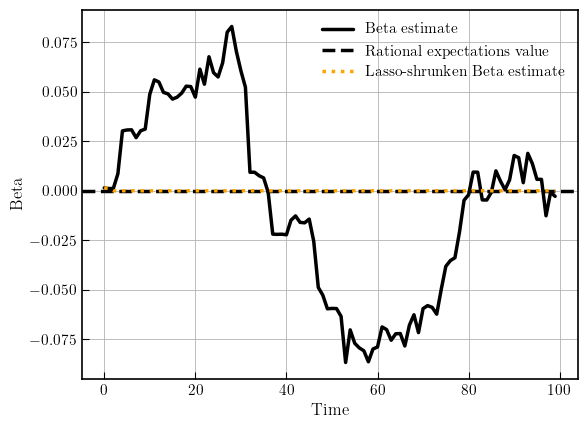

In [47]:
#visualize beta coefficient over time
fig, ax = plt.subplots()
ax.plot(beta, label='Beta estimate')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
#add lasso beta
ax.plot(beta_lasso, label='Lasso-shrunken Beta estimate', linestyle=':', color='orange')
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.legend()
plt.show()

## Multivariate case (2 is enough)

In [48]:
def multivariate_CGL_lasso(T, K, sigma_x, sigma, kappa, w, lambda_lasso):
    x = np.random.normal(0, sigma_x, (T, K)) # observable variables
    beta = np.zeros((T, K, 1)) # coefficients for the observable variables
    beta_lasso = np.zeros((T, K, 1)) # lasso-shrunken coefficients for the observable variables
    M = np.zeros((T, K, K))
    r = np.zeros(T)

    #Starting values
    beta[0, :, 0] = np.random.normal(0, 0.001, K) #small perturbation around REE
    beta[1, :, 0] = np.random.normal(0, 0.001, K)
    M[0, :, :] = np.eye(K) * sigma_x ** 2 # initial variance of the observable variables 
    r[1] = np.random.normal(0, 0.0001)

    for t in range(2, T):
        # update M
        M[t-1, :, :] = M[t-2, :, :] + (np.outer(x[t-2, :], x[t-2, :]) - M[t-2, :, :]) * constant_gain
        # update beta using RLS
        beta[t, :, 0] = beta[t-1, :, 0] + constant_gain * np.linalg.inv( M[t-1, :, :]) @ (x[t-2, :].reshape(-1, 1) * r[t-1] - (x[t-2, :].reshape(-1, 1) @ x[t-2, :].reshape(1, -1)) @ beta[t-1, :, 0].reshape(-1, 1)).flatten()
        # compute expected returns
        beta_lasso[t, :, 0] = lasso_from_beta_ols(beta[t, :, 0], lambda_lasso)
        r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)
    return beta, r, beta_lasso, x

In [49]:
beta, r, beta_lasso, x = multivariate_CGL_lasso(T=100, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, lambda_lasso=lambda_lasso)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_59799/2809274889.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


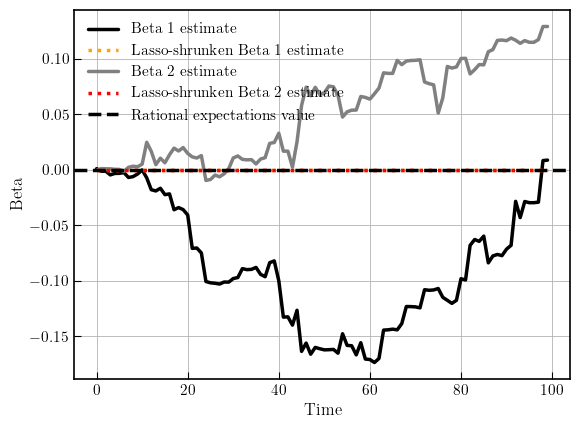

In [50]:
#visualzie the two betas over time
fig, ax = plt.subplots()
ax.plot(beta[:, 0, 0], label='Beta 1 estimate')
ax.plot(beta_lasso[:, 0, 0], label='Lasso-shrunken Beta 1 estimate', linestyle=':', color='orange')
ax.plot(beta[:, 1, 0], label='Beta 2 estimate', color = 'gray')
ax.plot(beta_lasso[:, 1, 0], label='Lasso-shrunken Beta 2 estimate', linestyle=':', color='red')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.legend()
plt.show()

In [51]:
## Check with multiple stochastic seeds to ensure robustness
num_simulations = 10
all_betas = []
all_betas_lasso = []
for sim in range(num_simulations):
    np.random.seed(sim)
    beta, r, beta_lasso, x = multivariate_CGL_lasso(T=100, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, lambda_lasso=lambda_lasso)
    all_betas.append(beta)
    all_betas_lasso.append(beta_lasso)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_59799/2809274889.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


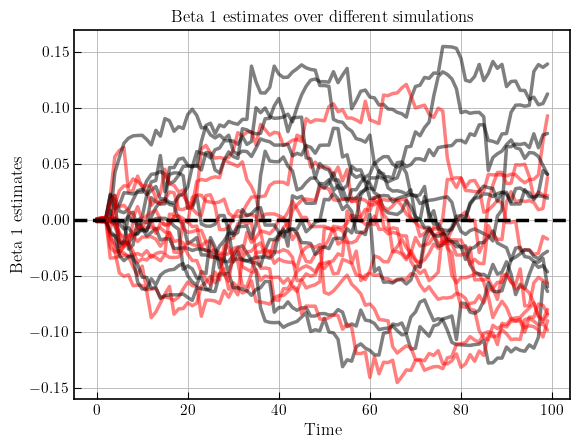

In [52]:
#visualization of coefficients over seeds
fig, ax = plt.subplots()
for sim in range(num_simulations):
    ax.plot(all_betas[sim][:, 0, 0], alpha=0.5, label = 'beta_1')
    ax.plot(all_betas[sim][:, 1, 0], alpha=0.5, color = 'red', label = 'beta_2')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
ax.set_ylabel('Beta 1 estimates')
ax.set_xlabel('Time')
ax.set_title('Beta 1 estimates over different simulations')
plt.show()

In [53]:
#generate long time series for K = 20 and T = 10000
beta, r, beta_lasso, x = multivariate_CGL_lasso(T=10000, K=20, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, lambda_lasso=lambda_lasso)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_59799/2809274889.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


In [54]:
from sklearn.linear_model import Lasso

In [55]:
def multivariate_CGL_offline_lasso(T, K, sigma_x, sigma, kappa, w, rolling_window_size = 30, lambda_lasso = 0.01, correct_with_tanh = True):
    
    #assert that rolling_window_size < T otherwise offline estimation is not possible
    assert rolling_window_size < T, "rolling_window_size must be less than T"

    x = np.random.normal(0, sigma_x, (T, K)) # observable variables
    beta_offline = np.zeros((T, K, 1))
    r_offline = np.zeros(T)

    #Starting values
    r_offline[1:rolling_window_size+1] = np.random.normal(0, 0.0001, rolling_window_size)


    for t in range(rolling_window_size+1, T):
        #generate x_current, up and including t-2
        x_current = x[t-rolling_window_size-1:t-1,:] #(x0, ... x299)
        r_offline_current = r_offline[t-rolling_window_size:t] # (r1, ... r300)
        beta_offline[t] = Lasso(alpha=lambda_lasso, fit_intercept=False, random_state=42).fit(x_current, r_offline_current).coef_.reshape(-1,1)
        if correct_with_tanh:
            r_offline[t] = (np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)).item()
        else:
            r_offline[t] = (np.log(1 - kappa * np.exp((beta_offline[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)))) - np.log(1 - kappa * np.exp((beta_offline[t, :, 0] @ x[t, :].reshape(-1, 1)))) + np.random.normal(0, sigma)).item() #r_301
    
    return beta_offline, r_offline, x

In [56]:
#simulate offline estimates
lambda_lasso = 0.00001
beta_offline, r_offline, x = multivariate_CGL_offline_lasso(T=10000, K=20, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, rolling_window_size=300, lambda_lasso=lambda_lasso, correct_with_tanh=False)

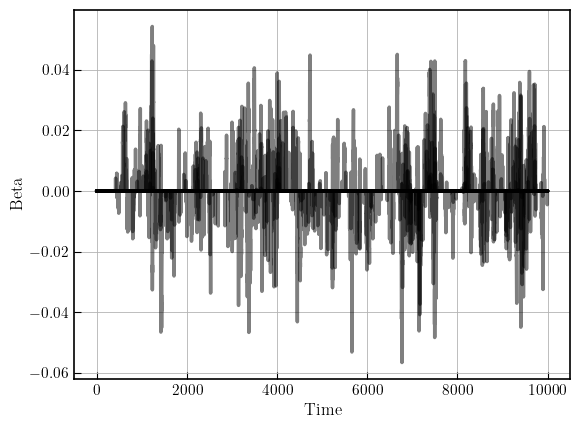

In [57]:
#visualize the lasso offline estimates
fig, ax = plt.subplots()
for k in range(beta_offline.shape[1]):
    ax.plot(beta_offline[:, k, 0], alpha = 0.5)
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
plt.show()

In [58]:
#create a dataset with x and r
#generate fictituous dates
import pandas as pd
dates = pd.date_range(start='2000-01-01', periods=10000, freq='D')
data = pd.DataFrame(data=x, index=dates, columns=[f'x_{i+1}' for i in range(x.shape[1])])
data['r'] = r_offline

#loop to save the betas
for i in range(beta_offline.shape[1]):
    data[f'beta_{i+1}'] = beta_offline[:, i, 0]

data.to_csv('simulation_data.csv')



## Distribution checks (constant gain OLS vs online LASSO)
We compare simulation output to the small-$\gamma$ theory: 
- $\beta^O$ approximately normal around 0.
- $\beta^L=S(\beta^O,\lambda/\sigma_x^2)$ is a soft-thresholded normal with a point mass at 0.


In [81]:
# Long simulation (univariate implemented as K=1 multivariate)
T_long = 20000
burn = 2000
K = 1
np.random.seed(1)

beta, r, beta_lasso, x = multivariate_CGL_lasso(T=T_long, K=K, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, lambda_lasso=lambda_lasso)

# extract series after burn-in
beta_O = beta[burn:, 0, 0]
beta_L = beta_lasso[burn:, 0, 0]


/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_59799/2809274889.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_lasso[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


In [82]:
# Theoretical quantities
# From the paper (local around 0): Var(beta_O) ≈ gamma * 0.5 * sigma^2 / sigma_x^2
var_betaO_theory = constant_gain * 0.5 * (sigma**2) / (sigma_x**2)
std_betaO_theory = np.sqrt(var_betaO_theory)

# Effective LASSO threshold for univariate penalized WLS: lambda / M ≈ lambda / sigma_x^2
thr = lambda_lasso / (sigma_x**2)

print('theory std(beta_O)=', std_betaO_theory)
print('effective threshold=', thr)


theory std(beta_O)= 0.07071067811865477
effective threshold= 0.1


In [83]:
# Empirical moments and normality check for beta_O
mean_O = beta_O.mean()
std_O = beta_O.std(ddof=1)
print('emp mean(beta_O)=', mean_O)
print('emp std(beta_O)=', std_O)

# Kolmogorov-Smirnov test against N(mean_O, std_O^2) (diagnostic, large n => very sensitive)
ks = stats.kstest((beta_O-mean_O)/std_O, 'norm')
print('KS stat, pvalue:', ks.statistic, ks.pvalue)


emp mean(beta_O)= 0.002082138766721503
emp std(beta_O)= 0.05581823996667374
KS stat, pvalue: 0.031959271811586865 2.0856432547563155e-16


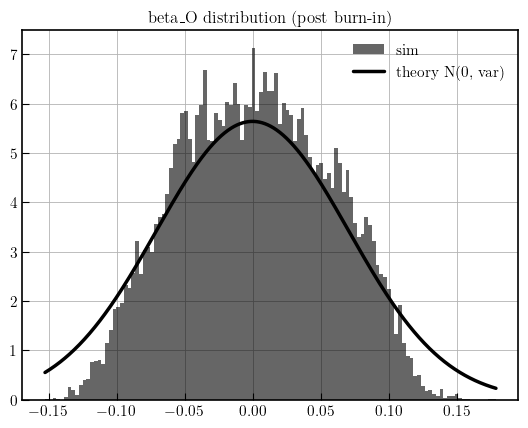

In [84]:
# Plot beta_O histogram with theory normal overlay
fig, ax = plt.subplots()
ax.hist(beta_O, bins=120, density=True, alpha=0.6, label='sim')
xx = np.linspace(beta_O.min(), beta_O.max(), 800)
ax.plot(xx, stats.norm.pdf(xx, 0.0, std_betaO_theory), label='theory N(0, var)')
ax.set_title('beta_O distribution (post burn-in)')
ax.legend()
plt.show()


In [85]:
beta_O.mean()

np.float64(0.002082138766721503)

In [86]:
# LASSO coefficient: point mass at 0 and tail shape
prob_nonzero_sim = np.mean(np.abs(beta_L) > 0)
# theory prob nonzero if beta_O ~ N(0, std_betaO_theory^2)
prob_nonzero_theory = 2*(1 - stats.norm.cdf(thr/std_betaO_theory))
print('P(beta_L != 0) sim   =', prob_nonzero_sim)
print('P(beta_L != 0) theory=', prob_nonzero_theory)


P(beta_L != 0) sim   = 0.058277777777777776
P(beta_L != 0) theory= 0.15729920705028522


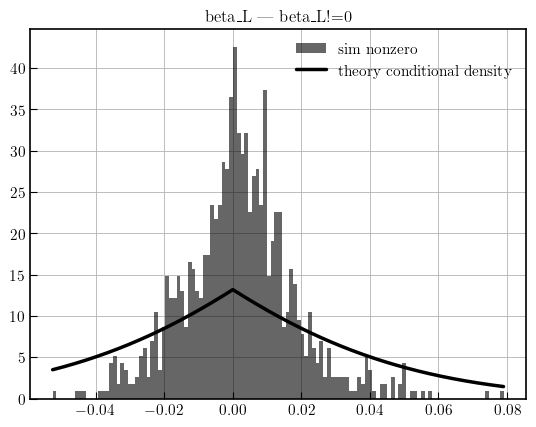

In [87]:
# Compare tail density of beta_L (conditioning on nonzero) to shifted normal tails
L_nz = beta_L[beta_L != 0]
fig, ax = plt.subplots()
ax.hist(L_nz, bins=120, density=True, alpha=0.6, label='sim nonzero')

# theory: if Y = S(X,thr) with X ~ N(0, std^2), then for y>0 density is phi(y+thr); for y<0 phi(y-thr)
std = std_betaO_theory
xx = np.linspace(L_nz.min(), L_nz.max(), 800)
# piecewise shifted density (unnormalized because conditional on nonzero would require division by prob_nonzero)
phi = lambda z: stats.norm.pdf(z, 0.0, std)
dens = np.where(xx>0, phi(xx+thr), phi(xx-thr))
# normalize to conditional density
dens = dens / prob_nonzero_theory
ax.plot(xx, dens, label='theory conditional density')
ax.set_title('beta_L | beta_L!=0')
ax.legend()
plt.show()
